In [ ]:
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# ML
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import (
    StandardScaler,
    OneHotEncoder,
    PolynomialFeatures
)
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

In [ ]:
# LOAD DATA
df = pd.read_csv('/content/data/train_energy_data.csv')

# KEEP FLOATS (IMPORTANT) - do not convert to int

# Statistical Summary

In [ ]:
df.shape

(1000, 7)

In [ ]:
df.columns

Index(['Building Type', 'Square Footage', 'Number of Occupants',
       'Appliances Used', 'Average Temperature', 'Day of Week',
       'Energy Consumption'],
      dtype='object')

In [ ]:
df.dtypes

,0
Building Type,object
Square Footage,int64
Number of Occupants,int64
Appliances Used,int64
Average Temperature,float64
Day of Week,object
Energy Consumption,float64


In [ ]:
df.isnull().sum()

,0
Building Type,0
Square Footage,0
Number of Occupants,0
Appliances Used,0
Average Temperature,0
Day of Week,0
Energy Consumption,0


In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Square Footage,1000.0,25462.38800,14294.554000,560.00,13169.7500,25477.000,37446.25,49997.00
Number of Occupants,1000.0,48.37200,29.061972,1.00,22.0000,47.000,73.25,99.00
Appliances Used,1000.0,25.60600,14.105166,1.00,13.0000,26.000,38.00,49.00
Average Temperature,1000.0,22.61139,7.139943,10.05,16.4750,22.815,28.85,34.99
Energy Consumption,1000.0,4166.25257,933.313064,1683.95,3509.4825,4175.730,4863.85,6530.60


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 7 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Building Type        1000 non-null   object 
 1   Square Footage       1000 non-null   int64  
 2   Number of Occupants  1000 non-null   int64  
 3   Appliances Used      1000 non-null   int64  
 4   Average Temperature  1000 non-null   float64
 5   Day of Week          1000 non-null   object 
 6   Energy Consumption   1000 non-null   float64
dtypes: float64(2), int64(3), object(2)
memory usage: 54.8+ KB


In [ ]:
numerical_cols = [
    'Square Footage',
    'Number of Occupants',
    'Appliances Used',
    'Average Temperature',
    'Energy Consumption'
]

# Distribution of Numerical Features

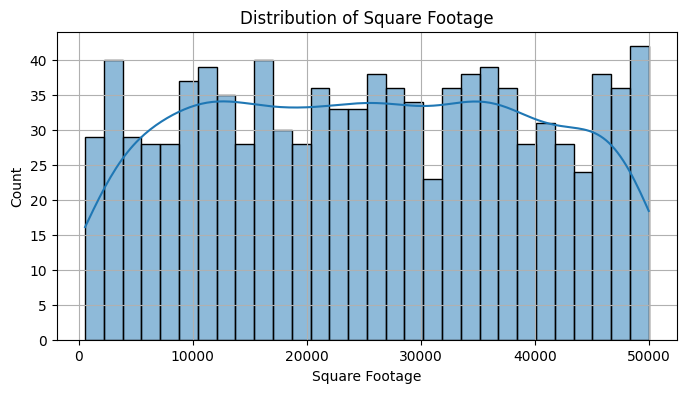

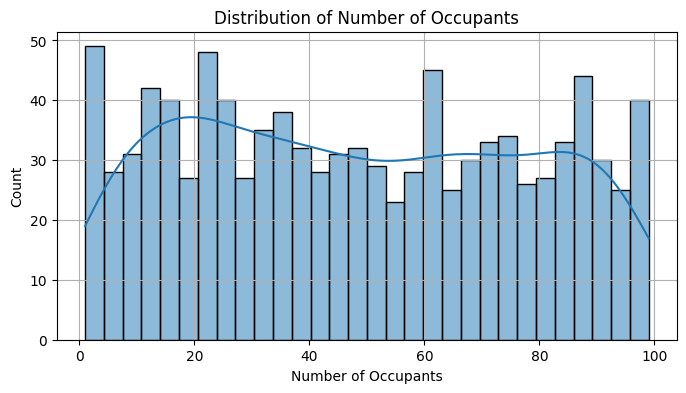

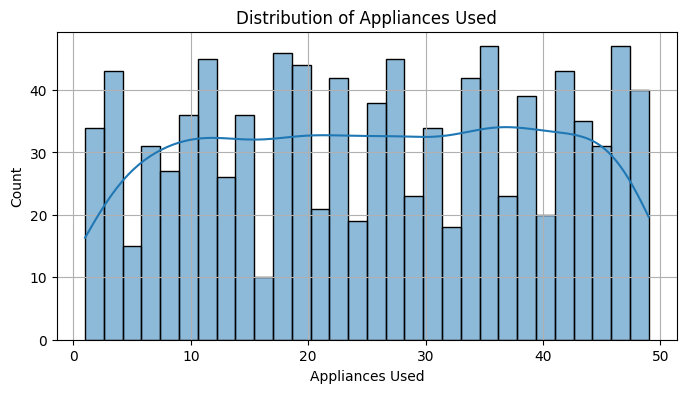

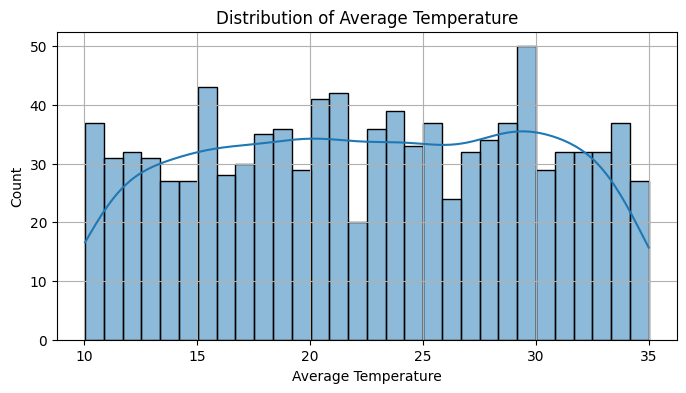

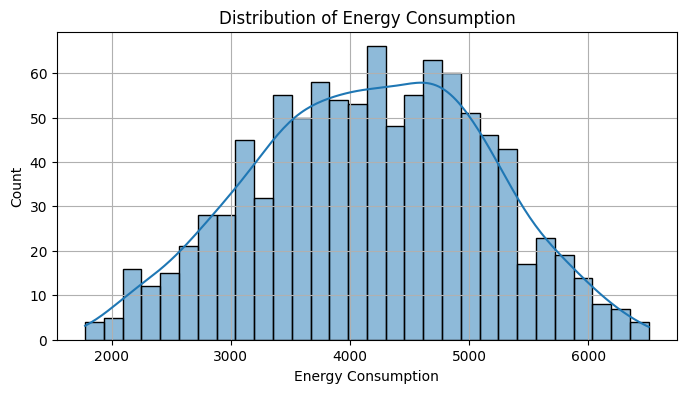

In [ ]:
for col in numerical_cols:

    plt.figure(figsize=(8,4))

    sns.histplot(df[col], kde=True, bins=30)

    plt.title(f'Distribution of {col}')

    plt.grid(True)

    plt.show()

# Boxplots for Outlier Detection

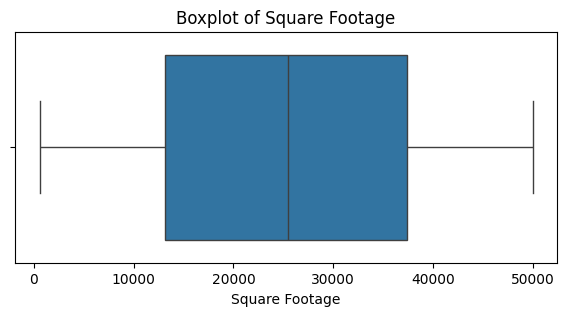

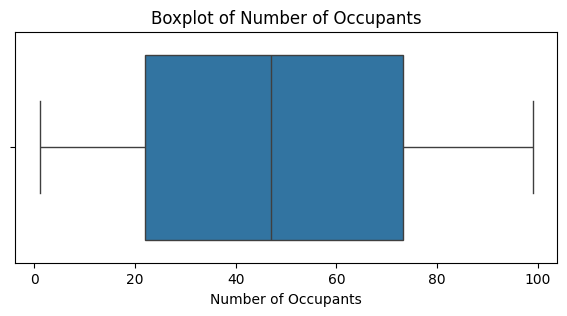

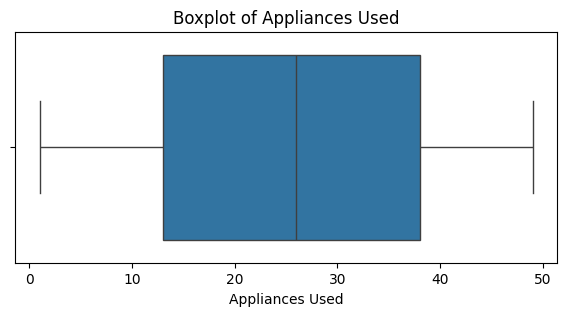

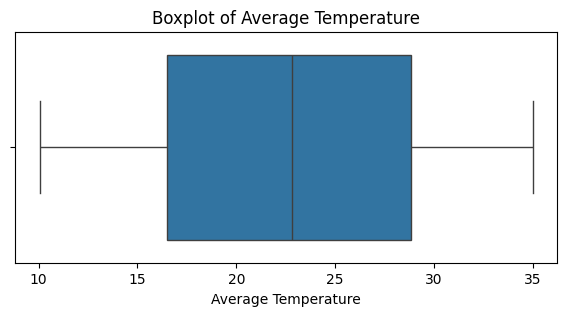

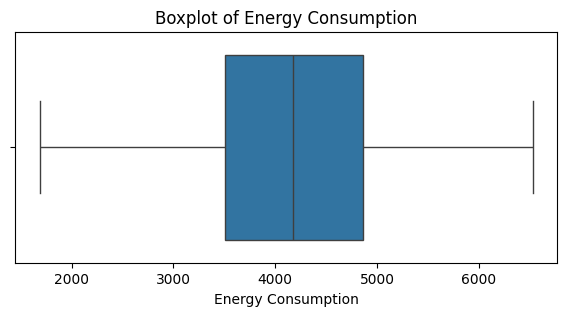

In [ ]:
for col in numerical_cols:

    plt.figure(figsize=(7,3))

    sns.boxplot(x=df[col])

    plt.title(f'Boxplot of {col}')

    plt.show()

# Correlation Heatmap

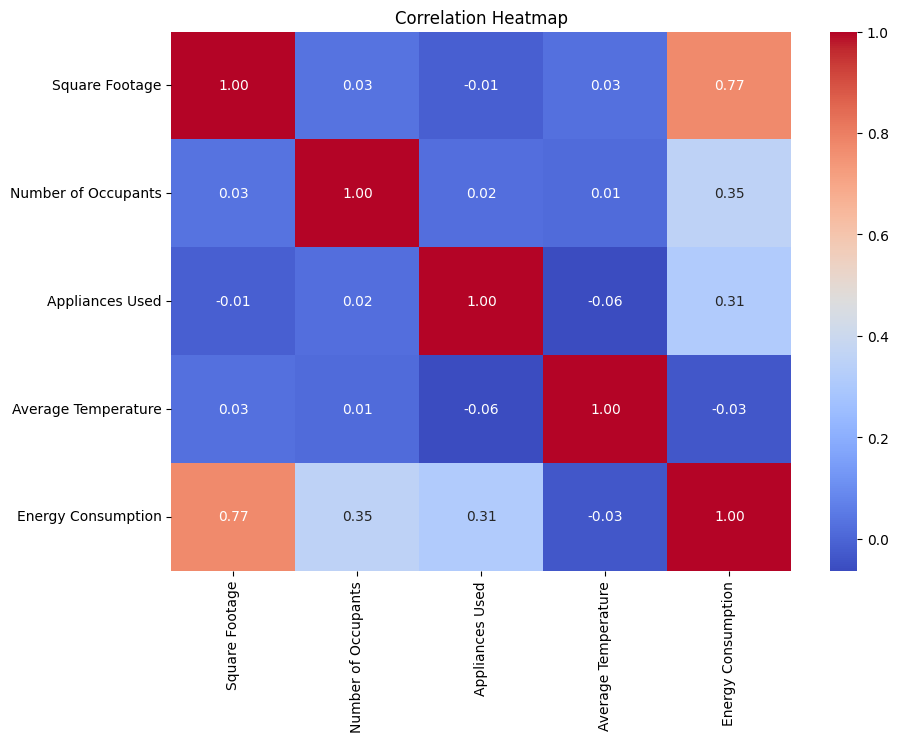

In [ ]:
plt.figure(figsize=(10,7))

corr = df.select_dtypes(include=['int64','float64']).corr()

sns.heatmap(
    corr,
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title('Correlation Heatmap')

plt.show()

# Pairplot - Relationships between all numerical variables

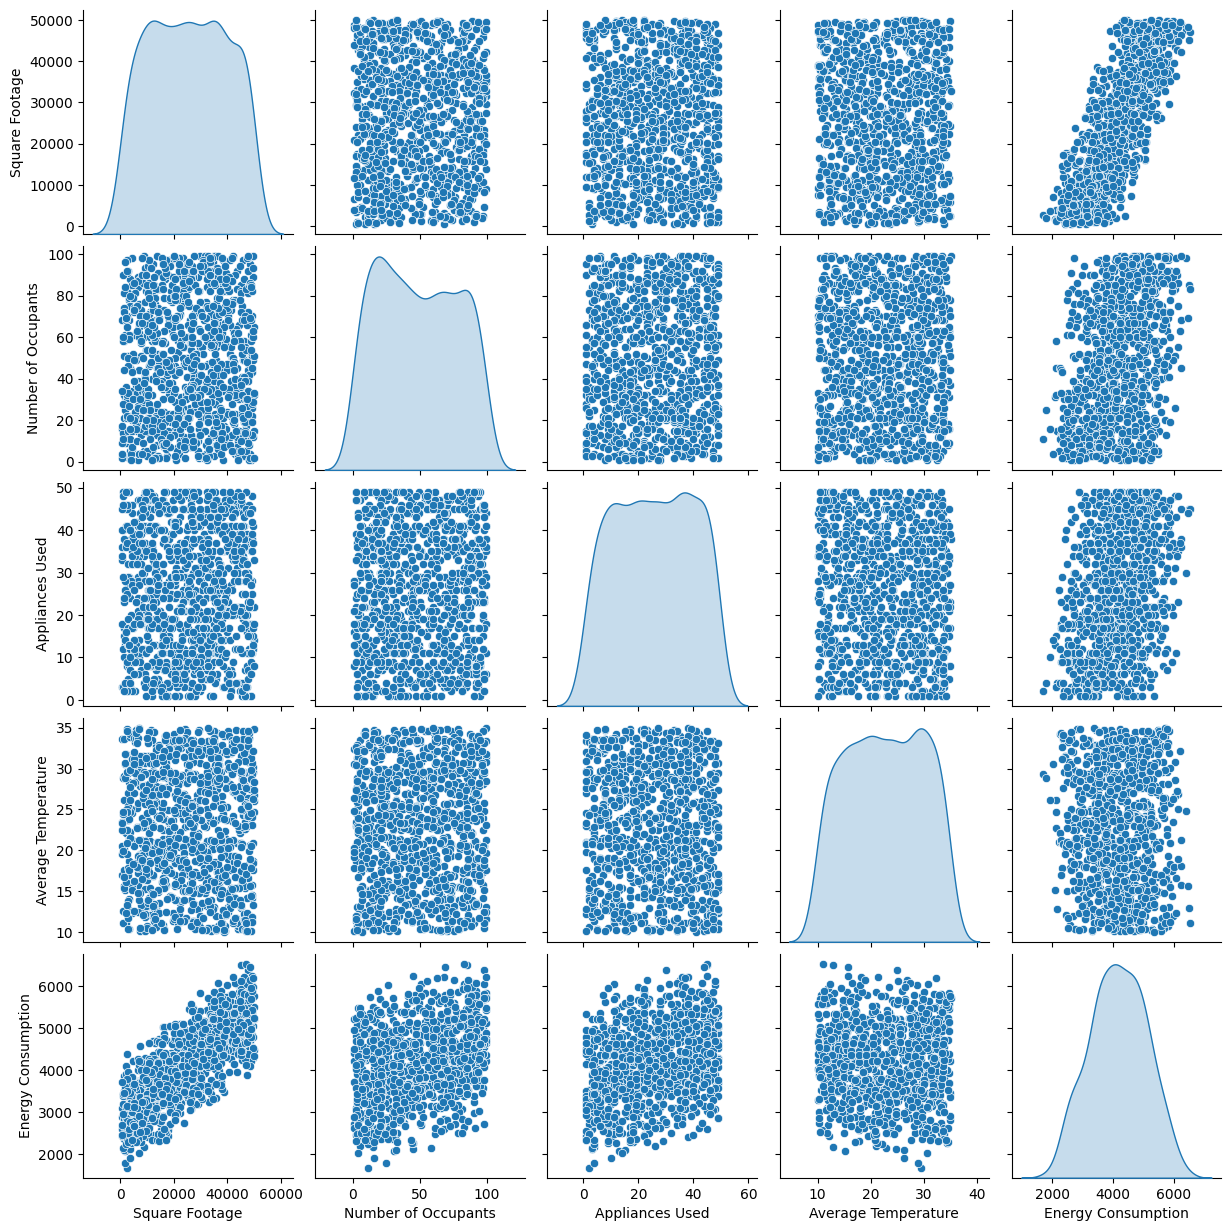

In [ ]:
sns.pairplot(
    df[numerical_cols],
    diag_kind='kde'
)

plt.show()

# Energy Consumption by Building Type

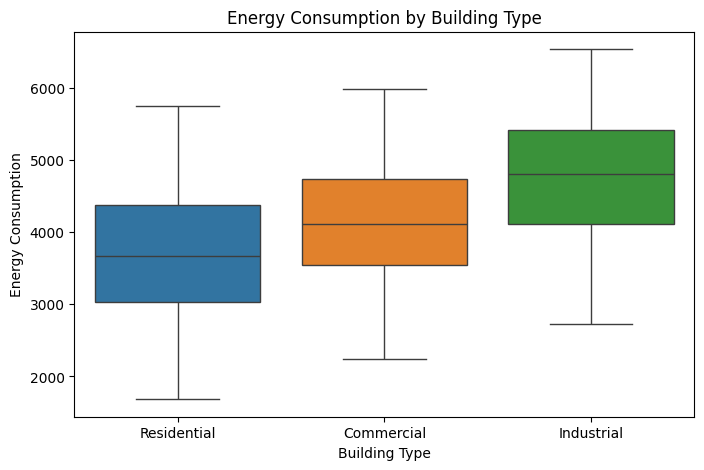

In [ ]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x='Building Type',
    y='Energy Consumption',
    hue='Building Type',
    legend=False
)

plt.title('Energy Consumption by Building Type')

plt.show()

# Average Energy Consumption

In [ ]:
avg_energy = df.groupby(
    'Building Type'
)['Energy Consumption'].mean()

print(avg_energy)

Building Type
Commercial     4130.023571
Industrial     4735.142618
Residential    3681.626628
Name: Energy Consumption, dtype: float64


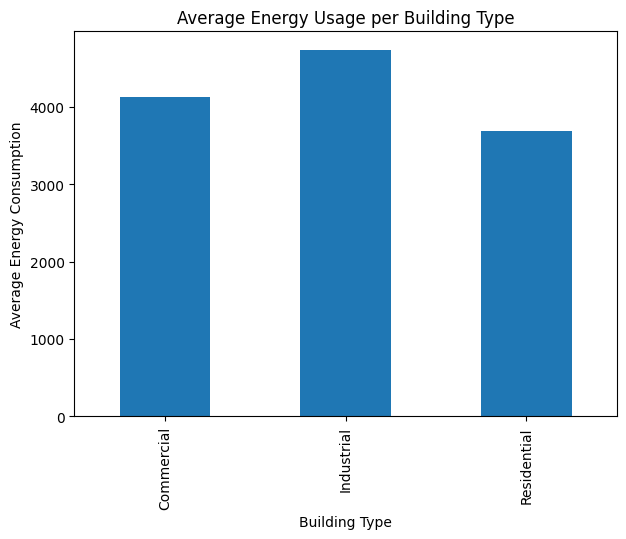

In [ ]:
avg_energy.plot(
    kind='bar',
    figsize=(7,5)
)

plt.ylabel('Average Energy Consumption')

plt.title('Average Energy Usage per Building Type')

plt.show()

# Square Footage vs Energy

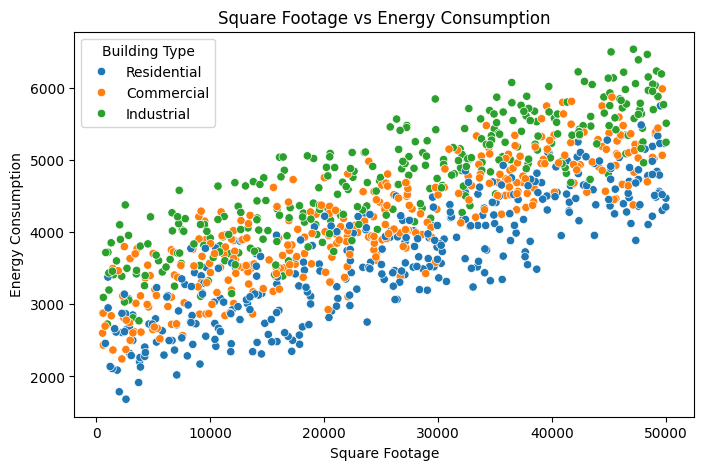

In [ ]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    data=df,
    x='Square Footage',
    y='Energy Consumption',
    hue='Building Type'
)

plt.title('Square Footage vs Energy Consumption')

plt.show()

# Appliances vs Energy

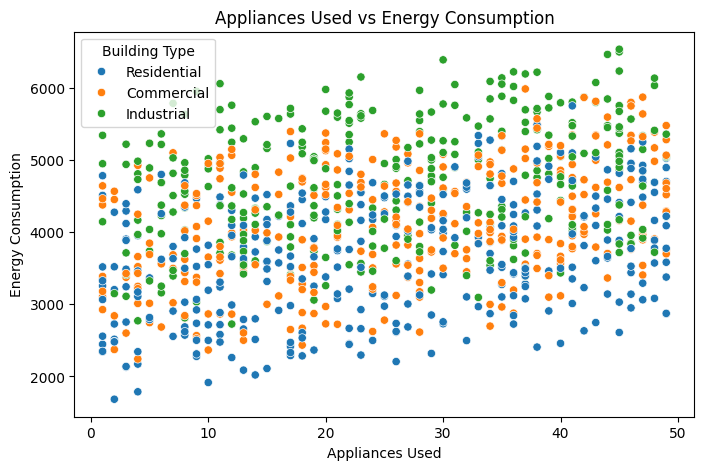

In [ ]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    data=df,
    x='Appliances Used',
    y='Energy Consumption',
    hue='Building Type'
)

plt.title('Appliances Used vs Energy Consumption')

plt.show()

# Categorical Countplots

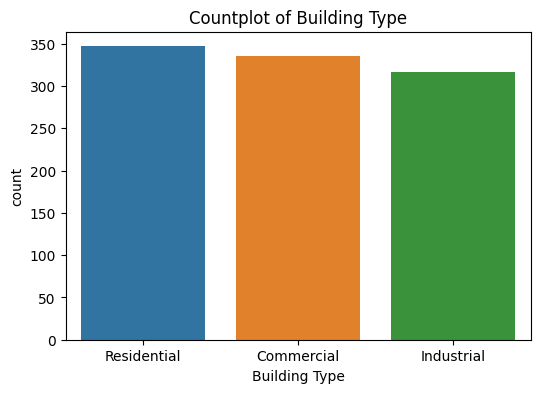

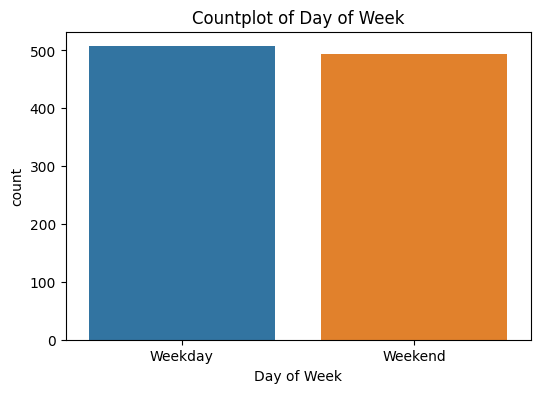

In [ ]:
categorical_cols = [
    'Building Type',
    'Day of Week'
]

for col in categorical_cols:

    plt.figure(figsize=(6,4))

    sns.countplot(
        data=df,
        x=col,
        hue=col,
        legend=False
    )

    plt.title(f'Countplot of {col}')

    plt.show()

# KDE Comparison

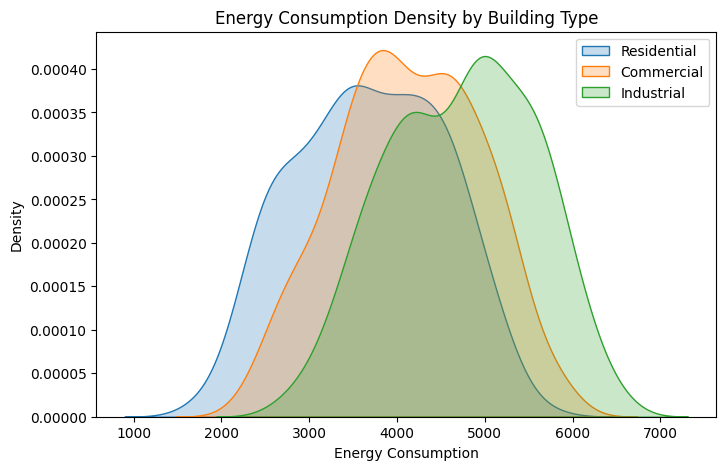

In [ ]:
plt.figure(figsize=(8,5))

for building in df['Building Type'].unique():

    subset = df[
        df['Building Type'] == building
    ]

    sns.kdeplot(
        subset['Energy Consumption'],
        label=building,
        fill=True
    )

plt.title('Energy Consumption Density by Building Type')

plt.legend()

plt.show()

# Regression lines

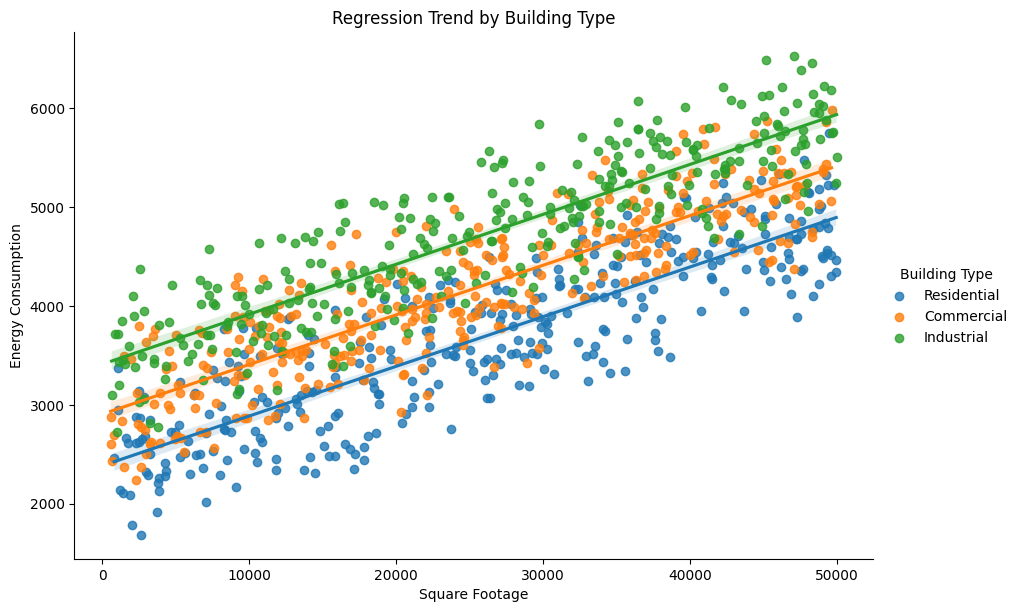

In [ ]:
sns.lmplot(
    data=df,
    x='Square Footage',
    y='Energy Consumption',
    hue='Building Type',
    height=6,
    aspect=1.5
)

plt.title('Regression Trend by Building Type')

plt.show()

# FEATURE ENGINEERING

In [ ]:
# Create new useful features
df['Occupants_per_Area'] = (
    df['Number of Occupants'] / df['Square Footage']
)

df['Appliances_per_Occupant'] = (
    df['Appliances Used'] / (df['Number of Occupants'] + 1)
)

df['Temp_x_Appliances'] = (
    df['Average Temperature'] * df['Appliances Used']
)

# OPTIONAL: LIGHT NOISE

In [ ]:
# Small realistic noise
np.random.seed(42)

noise = np.random.normal(
    loc=0,
    scale=df['Energy Consumption'].std() * 0.25,
    size=len(df)
)

df['Energy Consumption'] = (
    df['Energy Consumption'] + noise
)

# OUTLIER REMOVAL

In [ ]:
numerical_cols = [
    'Square Footage',
    'Number of Occupants',
    'Appliances Used',
    'Average Temperature',
    'Energy Consumption'
]

clean_df = df.copy()

for col in numerical_cols:
    Q1 = clean_df[col].quantile(0.25)
    Q3 = clean_df[col].quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    clean_df = clean_df[
        (clean_df[col] >= lower) &
        (clean_df[col] <= upper)
    ]

print("Clean Shape:", clean_df.shape)

# USE CLEAN DATA
df = clean_df.copy()

Clean Shape: (1000, 10)


# FEATURES & TARGET

In [ ]:
X = df.drop('Energy Consumption', axis=1)
y = df['Energy Consumption']

# CATEGORICAL & NUMERICAL COLUMNS

In [ ]:
categorical_cols = [
    'Building Type',
    'Day of Week'
]

numerical_cols = [
    col for col in X.columns
    if col not in categorical_cols
]

# PREPROCESSOR

In [ ]:
preprocessor = ColumnTransformer(
    transformers=[
        (
            'num',
            Pipeline([
                ('scaler', StandardScaler()),
                ('poly', PolynomialFeatures(
                    degree=1,
                    include_bias=False
                ))
            ]),
            numerical_cols
        ),
        (
            'cat',
            OneHotEncoder(drop='first'),
            categorical_cols
        )
    ]
)

# TRAIN TEST SPLIT

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# MODEL PIPELINE

In [ ]:
model = Pipeline([
    ('preprocessor', preprocessor),
    ('regressor', LinearRegression())
])

# TRAIN

In [ ]:
model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('scaler',
                                                                   StandardScaler()),
                                                                  ('poly',
                                                                   PolynomialFeatures(degree=1,
                                                                                      include_bias=False))]),
                                                  ['Square Footage',
                                                   'Number of Occupants',
                                                   'Appliances Used',
                                                   'Average Temperature',
                                                   'Occupants_per_Area',
                                                   'Appliances_per_Occupant',
                                                   'Temp_x_Appliances']),
                                                 ('cat',
                                                  OneHotEncoder(drop='first'),
                                                  ['Building Type',
                                                   'Day of Week'])])),
                ('regressor', LinearRegression())])

# PREDICT

In [ ]:
y_pred = model.predict(X_test)

# EVALUATION

In [ ]:
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("\n===== MODEL PERFORMANCE =====")
print("MAE  :", mae)
print("MSE  :", mse)
print("RMSE :", rmse)
print("R2   :", r2)


===== MODEL PERFORMANCE =====
MAE  : 184.0178007042245
MSE  : 53698.25037272688
RMSE : 231.72882939489182
R2   : 0.937334606996323


# CROSS VALIDATION

In [ ]:
cv_scores = cross_val_score(
    model,
    X,
    y,
    cv=5,
    scoring='r2'
)

print("\nCross Validation R2 Scores:")
print(cv_scores)

print("\nAverage CV R2:", cv_scores.mean())


Cross Validation R2 Scores:
[0.95383302 0.94122985 0.93894922 0.93037573 0.94210385]

Average CV R2: 0.9412983331741801


# FEATURE IMPORTANCE

In [ ]:
# GET FEATURE NAMES AFTER PREPROCESSING

feature_names = model.named_steps[
    'preprocessor'
].get_feature_names_out()

# GET COEFFICIENTS

coefficients = model.named_steps[
    'regressor'
].coef_

# CREATE DATAFRAME

importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Coefficient': coefficients
})

# ABSOLUTE IMPORTANCE

importance_df['Absolute_Coefficient'] = (
    importance_df['Coefficient'].abs()
)

# SORT

importance_df = importance_df.sort_values(
    by='Absolute_Coefficient',
    ascending=False
)

print("\nTop Important Features:")
print(importance_df.head(10))


Top Important Features:
                          Feature  Coefficient  Absolute_Coefficient
0             num__Square Footage   714.263887            714.263887
7   cat__Building Type_Industrial   498.205883            498.205883
8  cat__Building Type_Residential  -497.710577            497.710577
1        num__Number of Occupants   285.202398            285.202398
2            num__Appliances Used   280.269545            280.269545
9        cat__Day of Week_Weekend   -73.347416             73.347416
3        num__Average Temperature   -25.984236             25.984236
4         num__Occupants_per_Area   -17.626044             17.626044
5    num__Appliances_per_Occupant   -12.040921             12.040921
6          num__Temp_x_Appliances     2.303515              2.303515


# PREDICTION VS ACTUAL

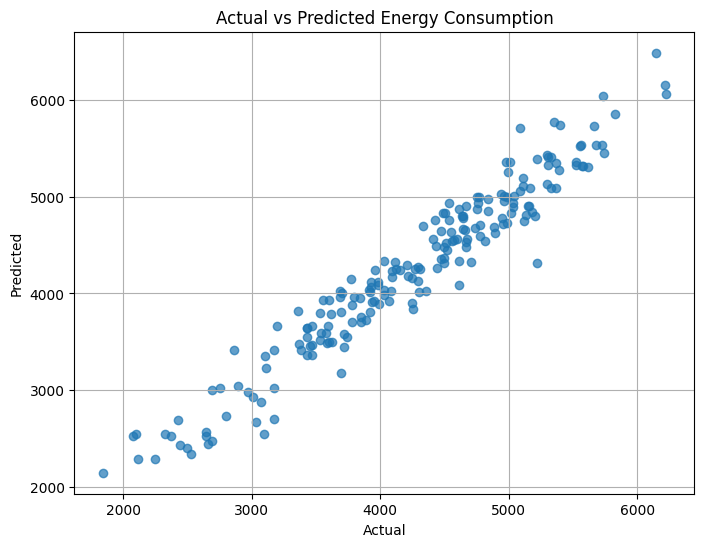

In [ ]:
plt.figure(figsize=(8,6))

plt.scatter(y_test, y_pred, alpha=0.7)

plt.xlabel("Actual")
plt.ylabel("Predicted")

plt.title("Actual vs Predicted Energy Consumption")

plt.grid(True)

plt.show()

# Actual vs Predicted Plot

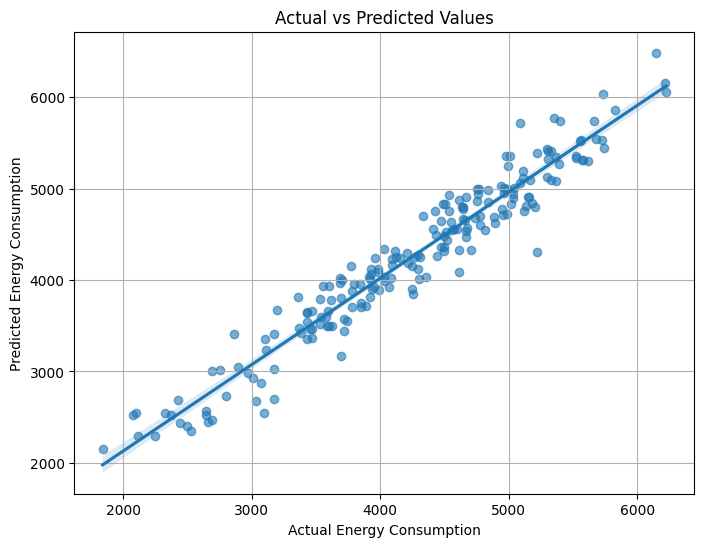

In [ ]:
plt.figure(figsize=(8,6))

sns.regplot(
    x=y_test,
    y=y_pred,
    scatter_kws={'alpha':0.6}
)

plt.xlabel("Actual Energy Consumption")
plt.ylabel("Predicted Energy Consumption")

plt.title("Actual vs Predicted Values")

plt.grid(True)

plt.show()

# Residual Plot

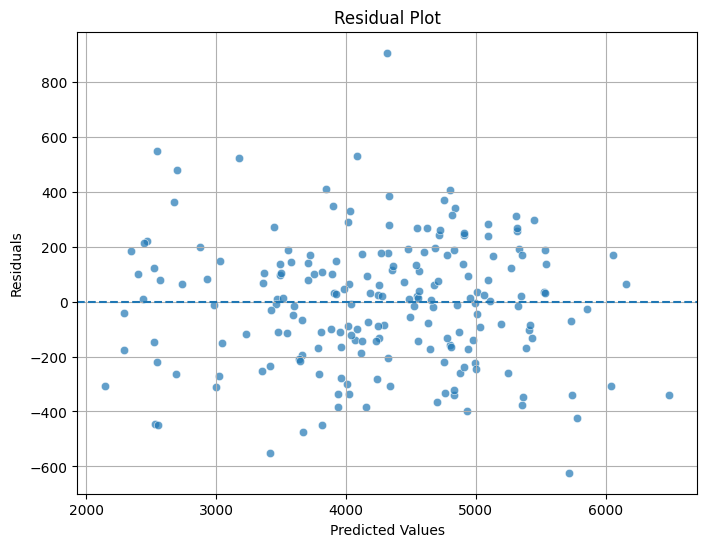

In [ ]:
residuals = y_test - y_pred

plt.figure(figsize=(8,6))

sns.scatterplot(
    x=y_pred,
    y=residuals,
    alpha=0.7
)

plt.axhline(
    y=0,
    linestyle='--'
)

plt.xlabel("Predicted Values")
plt.ylabel("Residuals")

plt.title("Residual Plot")

plt.grid(True)

plt.show()

# Distribution of Residuals

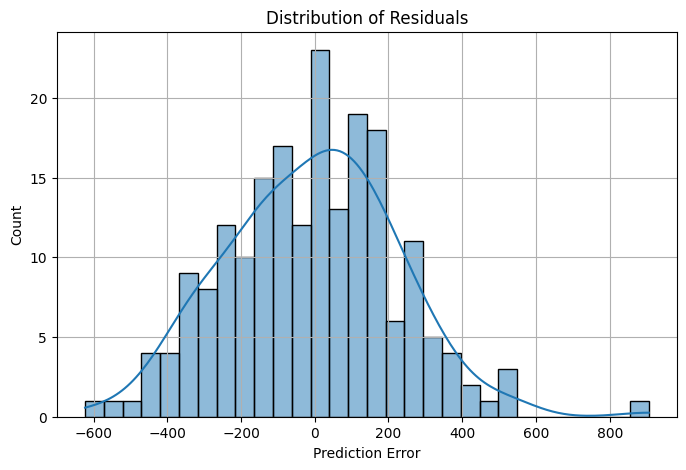

In [ ]:
plt.figure(figsize=(8,5))

sns.histplot(
    residuals,
    kde=True,
    bins=30
)

plt.title("Distribution of Residuals")

plt.xlabel("Prediction Error")

plt.grid(True)

plt.show()

# Feature Importance Plot

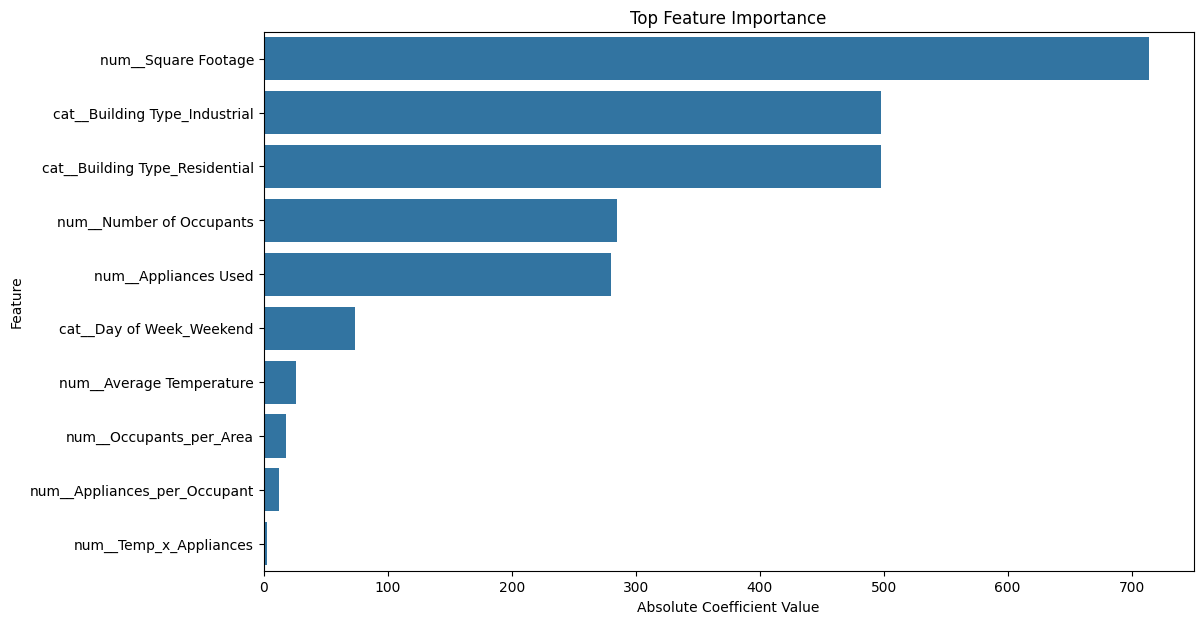

In [ ]:
# GET FEATURE NAMES

feature_names = model.named_steps[
    'preprocessor'
].get_feature_names_out()

# GET COEFFICIENTS

coefficients = model.named_steps[
    'regressor'
].coef_

# CREATE DATAFRAME

importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Coefficient': coefficients
})

# USE ABSOLUTE VALUE FOR IMPORTANCE

importance_df['Importance'] = (
    importance_df['Coefficient'].abs()
)

# SORT

importance_df = importance_df.sort_values(
    by='Importance',
    ascending=False
)

# TOP FEATURES

top_features = importance_df.head(15)

# PLOT

plt.figure(figsize=(12, 7))

sns.barplot(
    data=top_features,
    x='Importance',
    y='Feature'
)

plt.title("Top Feature Importance")
plt.xlabel("Absolute Coefficient Value")
plt.ylabel("Feature")

plt.show()

# Error Metrics Bar Chart

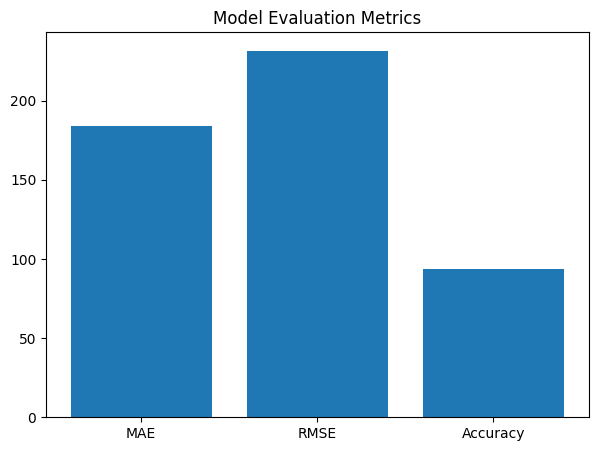

In [ ]:
metrics = {
    'MAE': mae,
    'RMSE': rmse,
    'Accuracy': r2*100
}

plt.figure(figsize=(7,5))

plt.bar(
    metrics.keys(),
    metrics.values()
)

plt.title("Model Evaluation Metrics")

plt.show()

# Cross Validation Scores Plot

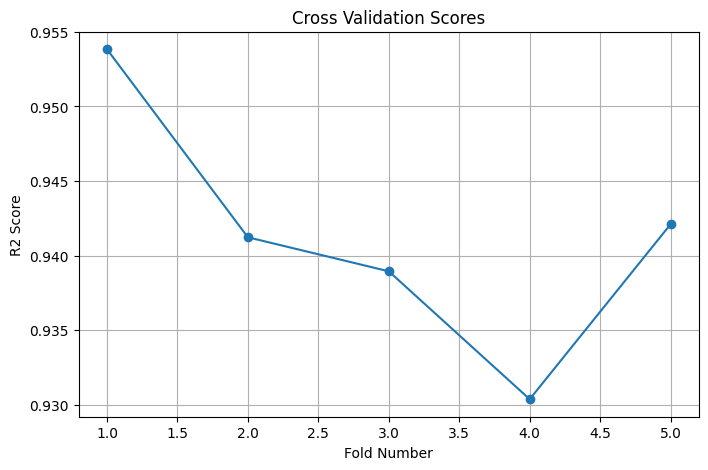

In [ ]:
plt.figure(figsize=(8,5))

plt.plot(
    range(1, len(cv_scores)+1),
    cv_scores,
    marker='o'
)

plt.xlabel("Fold Number")
plt.ylabel("R2 Score")

plt.title("Cross Validation Scores")

plt.grid(True)

plt.show()

# Prediction Error Line Plot

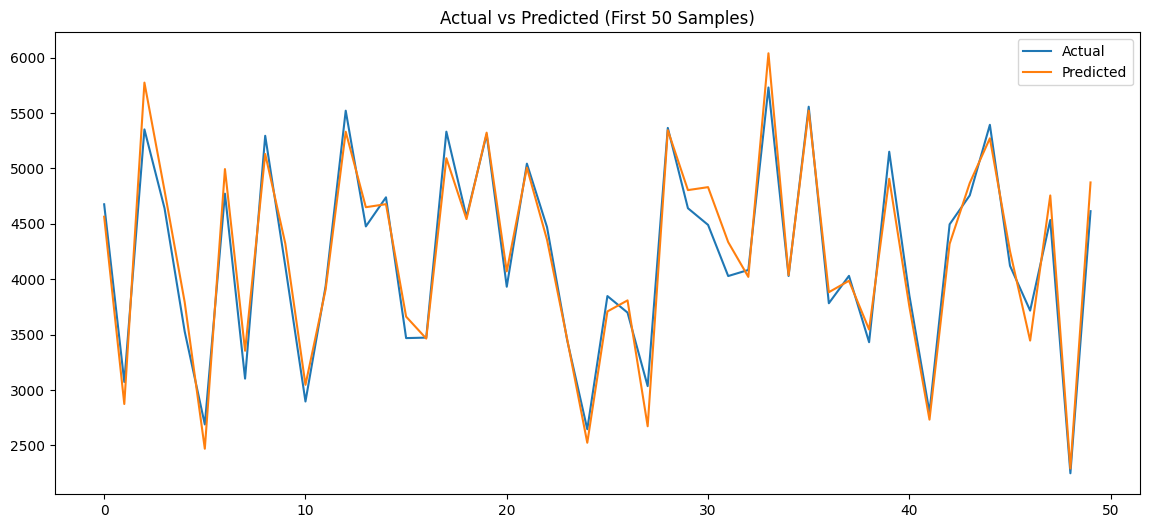

In [ ]:
comparison_df = pd.DataFrame({
    'Actual': y_test.values,
    'Predicted': y_pred
}).reset_index(drop=True)

comparison_df = comparison_df.head(50)

plt.figure(figsize=(14,6))

plt.plot(comparison_df['Actual'], label='Actual')

plt.plot(comparison_df['Predicted'], label='Predicted')

plt.legend()

plt.title("Actual vs Predicted (First 50 Samples)")

plt.show()

# Learning Curve

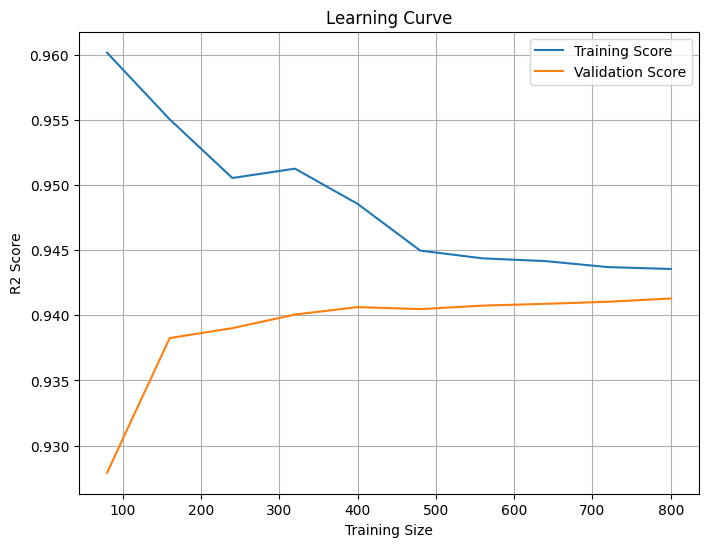

In [ ]:
from sklearn.model_selection import learning_curve

# LEARNING CURVE

train_sizes, train_scores, test_scores = learning_curve(
    model,
    X,
    y,
    cv=5,
    scoring='r2',
    train_sizes=np.linspace(0.1, 1.0, 10)
)

# MEAN SCORES

train_mean = train_scores.mean(axis=1)
test_mean = test_scores.mean(axis=1)

# PLOT

plt.figure(figsize=(8, 6))

plt.plot(
    train_sizes,
    train_mean,
    label='Training Score'
)

plt.plot(
    train_sizes,
    test_mean,
    label='Validation Score'
)

plt.xlabel("Training Size")
plt.ylabel("R2 Score")

plt.title("Learning Curve")

plt.legend()

plt.grid(True)

plt.show()

# Code building for deployment

In [5]:
# Import numerical computing library
import numpy as np

# Import data handling library
import pandas as pd

# ==============================
# DATA VISUALIZATION LIBRARIES
# ==============================

# Import plotting library
import matplotlib.pyplot as plt

# Import advanced visualization library
import seaborn as sns

# ==============================
# MACHINE LEARNING LIBRARIES
# ==============================

# Import function to split dataset into training and testing sets
from sklearn.model_selection import train_test_split, cross_val_score

# Import preprocessing tools
from sklearn.preprocessing import (
    StandardScaler,      # Standardize numerical data
    OneHotEncoder,       # Convert categorical data into numerical format
    PolynomialFeatures   # Create polynomial features
)

# Import column transformer for applying different preprocessing
from sklearn.compose import ColumnTransformer

# Import pipeline to combine preprocessing and model
from sklearn.pipeline import Pipeline

# Import Linear Regression model
from sklearn.linear_model import LinearRegression

# Import evaluation metrics
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

# ==============================
# LOAD DATASET
# ==============================

# Read CSV file into dataframe
df = pd.read_csv('/content/data/train_energy_data.csv')

# ==============================
# ADD RANDOM NOISE
# ==============================

# Set random seed for reproducibility
np.random.seed(42)

# Generate small realistic noise
noise = np.random.normal(
    loc=0,   # Mean of noise
    scale=df['Energy Consumption'].std() * 0.25,  # Noise strength
    size=len(df)  # Number of noise values
)

# Add noise to target column
df['Energy Consumption'] = (
    df['Energy Consumption'] + noise
)

# ==============================
# OUTLIER REMOVAL USING IQR
# ==============================

# Numerical columns for outlier detection
numerical_cols = [
    'Square Footage',
    'Number of Occupants',
    'Appliances Used',
    'Average Temperature',
    'Energy Consumption'
]

# Create copy of dataframe
clean_df = df.copy()

# Loop through each numerical column
for col in numerical_cols:

    # Calculate first quartile (25%)
    Q1 = clean_df[col].quantile(0.25)

    # Calculate third quartile (75%)
    Q3 = clean_df[col].quantile(0.75)

    # Calculate Interquartile Range
    IQR = Q3 - Q1

    # Define lower boundary
    lower = Q1 - 1.5 * IQR

    # Define upper boundary
    upper = Q3 + 1.5 * IQR

    # Keep only rows inside boundaries
    clean_df = clean_df[
        (clean_df[col] >= lower) &
        (clean_df[col] <= upper)
    ]

# Print cleaned dataset shape
print("Clean Shape:", clean_df.shape)

# ==============================
# USE CLEANED DATA
# ==============================

# Replace original dataframe with cleaned dataframe
df = clean_df.copy()

# ==============================
# DEFINE FEATURES AND TARGET
# ==============================

# Features (independent variables)
X = df.drop('Energy Consumption', axis=1)

# Target variable (dependent variable)
y = df['Energy Consumption']

# Categorical columns
categorical_cols = [
    'Building Type',
    'Day of Week'
]

# Numerical columns
numerical_cols = [
    col for col in X.columns
    if col not in categorical_cols
]

# ==============================
# DATA PREPROCESSING
# ==============================

# Create preprocessing pipeline
preprocessor = ColumnTransformer(
    transformers=[

        # Numerical preprocessing
        (
            'num',
            Pipeline([

                # Standardize numerical data
                ('scaler', StandardScaler()),

                # Generate polynomial features
                ('poly', PolynomialFeatures(
                    degree=1,          # Linear features only
                    include_bias=False
                ))
            ]),
            numerical_cols
        ),

        # Categorical preprocessing
        (
            'cat',

            # Convert categories into dummy variables
            OneHotEncoder(drop='first'),

            categorical_cols
        )
    ]
)

# ==============================
# TRAIN TEST SPLIT
# ==============================

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,   # 20% test data
    random_state=42
)

# ==============================
# CREATE MACHINE LEARNING MODEL
# ==============================

# Create complete pipeline
model = Pipeline([

    # Apply preprocessing
    ('preprocessor', preprocessor),

    # Apply Linear Regression
    ('regressor', LinearRegression())
])

# ==============================
# TRAIN MODEL
# ==============================

# Train model on training data
model.fit(X_train, y_train)

# ==============================
# MAKE PREDICTIONS
# ==============================

# Predict values on test data
y_pred = model.predict(X_test)

# ==============================
# MODEL EVALUATION
# ==============================

# Mean Absolute Error
mae = mean_absolute_error(y_test, y_pred)

# Mean Squared Error
mse = mean_squared_error(y_test, y_pred)

# Root Mean Squared Error
rmse = np.sqrt(mse)

# R² Score
r2 = r2_score(y_test, y_pred)

# ==============================
# PRINT RESULTS
# ==============================

print("\n===== MODEL PERFORMANCE =====")

print("MAE  :", mae)
print("MSE  :", mse)
print("RMSE :", rmse)
print("R2   :", r2)

Clean Shape: (1000, 7)

===== MODEL PERFORMANCE =====
MAE  : 182.60698998709879
MSE  : 52344.27888250993
RMSE : 228.78872105615244
R2   : 0.9389146799961188


In [7]:
# LOAD TEST DATA
test_df = pd.read_csv('/content/data/test_energy_data.csv')

# Features and target
X_test_external = test_df.drop('Energy Consumption', axis=1)
y_test_external = test_df['Energy Consumption']

# Predict using trained model
y_pred_external = model.predict(X_test_external)

# Evaluation
external_mae = mean_absolute_error(
    y_test_external,
    y_pred_external
)

external_mse = mean_squared_error(
    y_test_external,
    y_pred_external
)

external_rmse = np.sqrt(external_mse)

external_r2 = r2_score(
    y_test_external,
    y_pred_external
)

print("\n===== EXTERNAL TEST RESULTS =====")
print("MAE  :", external_mae)
print("MSE  :", external_mse)
print("RMSE :", external_rmse)
print("R2   :", external_r2)


===== EXTERNAL TEST RESULTS =====
MAE  : 15.629233920038683
MSE  : 377.6565175752611
RMSE : 19.43338667281802
R2   : 0.9994496602738069


# Save Trained Model

In [8]:
import joblib

# Save trained pipeline
joblib.dump(model, 'energy_model.pkl')

print("Model saved successfully!")

Model saved successfully!
